# Imports

In [1]:
# Clean incompatible HF stack
!pip uninstall -y transformers accelerate peft trl sentence-transformers datasets evaluate

# Install compatible versions for granite-tsfm v0.2.22
!pip install transformers==4.40.2 accelerate==0.31.0

# Reinstall granite-tsfm
!pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.22"

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: accelerate 0.31.0
Uninstalling accelerate-0.31.0:
  Successfully uninstalled accelerate-0.31.0
Found existing installation: datasets 4.8.3
Uninstalling datasets-4.8.3:
  Successfully uninstalled datasets-4.8.3
  Using cached transformers-4.40.2-py3-none-any.whl.metadata (137 kB)
  Using cached accelerate-0.31.0-py3-none-any.whl.metadata (19 kB)
Using cached transformers-4.40.2-py3-none-any.whl (9.0 MB)
Using cached accelerate-0.31.0-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers] [transformers]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
granite-tsfm 0.2.22 requires datasets, which is not installed.
  Cloning https://github.com/ibm-granite/granite-tsfm.git (to 

In [2]:
import transformers, accelerate
print(transformers.__version__)
print(accelerate.__version__)

W0329 11:28:24.694000 91350 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


4.40.2
0.31.0


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments

In [5]:
import math
import os
import tempfile

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK

from tsfm_public import TimeSeriesPreprocessor, TrackingCallback, count_parameters, get_datasets
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions

In [6]:
import warnings


# Suppress all warnings
warnings.filterwarnings("ignore")

# Data Processing

In [7]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# Dataset
TARGET_DATASET = "segment_50"
dataset_path = "https://media.githubusercontent.com/media/arnavthak/TTM_test_data/refs/heads/main/segment_50.csv"
timestamp_column = "time"
#id_columns = ["segment_id"]
#target_columns = ["pSphincter", "pGastric", "amplitude", "frequency", "pulse_width", "stim_on", "rel_time"]

TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)

data["rel_time"] = pd.to_timedelta(data["rel_time"]).dt.total_seconds()

data.head()

,segment_id,time,pSphincter,pGastric,amplitude,frequency,pulse_width,stim_on,rel_time
0,segment_50,2025-01-22 12:09:54,23.901768,58.582094,14,10000,0.0002,0,-10.0
1,segment_50,2025-01-22 12:09:54,23.924541,58.870277,14,10000,0.0002,0,-9.0
2,segment_50,2025-01-22 12:09:54,23.929061,59.113002,14,10000,0.0002,0,-9.0
3,segment_50,2025-01-22 12:09:54,24.030849,58.357680,14,10000,0.0002,0,-9.0
4,segment_50,2025-01-22 12:09:54,24.114434,56.948451,14,10000,0.0002,0,-9.0


In [8]:
def create_augmented_dataset(
    df,
    context_length=90,
    forecast_length=30,
    stride=1,
):
    """
    Creates dataset for paper approach:
    (context, theta, delta) -> future
    """

    X_context = []
    X_theta = []
    X_delta = []
    Y_target = []

    # Extract arrays for speed
    p = df[["pSphincter", "pGastric"]].values
    theta = df[["amplitude", "frequency", "pulse_width"]].values
    rel_time = df["rel_time"].values

    N = len(df)

    for t in range(context_length, N - forecast_length, stride):

        # ----- Context -----
        context = p[t - context_length : t]

        # ----- Target -----
        target = p[t : t + forecast_length]

        # ----- Conditioning -----
        theta_t = theta[t]        # constant per segment
        delta_t = rel_time[t]     # scalar

        # Store
        X_context.append(context)
        X_theta.append(theta_t)
        X_delta.append(delta_t)
        Y_target.append(target)

    return (
        np.array(X_context),
        np.array(X_theta),
        np.array(X_delta),
        np.array(Y_target),
    )

In [9]:
dataset = create_augmented_dataset(data)

dataset

(array([[[23.90176787, 58.58209375],
         [23.92454106, 58.87027734],
         [23.92906084, 59.11300195],
         ...,
         [23.95484722, 32.71349023],
         [23.89556719, 32.33433984],
         [23.98677202, 32.48692773]],
 
        [[23.92454106, 58.87027734],
         [23.92906084, 59.11300195],
         [24.03084917, 58.35767969],
         ...,
         [23.89556719, 32.33433984],
         [23.98677202, 32.48692773],
         [23.73144829, 32.15767969]],
 
        [[23.92906084, 59.11300195],
         [24.03084917, 58.35767969],
         [24.11443389, 56.94845117],
         ...,
         [23.98677202, 32.48692773],
         [23.73144829, 32.15767969],
         [23.83327397, 32.10626367]],
 
        ...,
 
        [[30.34446489, 30.226625  ],
         [30.16816875, 30.83968652],
         [30.17576396, 31.46392969],
         ...,
         [30.07241924, 90.00421289],
         [30.12105352, 90.7990127 ],
         [30.025304  , 90.0794082 ]],
 
        [[30.16816875, 30.839

In [10]:
def create_random_splits(dataset, train_size=50_000, val_size=50_000, test_size=50_000, seed=42):
    """
    Creates non-overlapping random splits from dataset.
    """

    np.random.seed(seed)

    # Unpack
    X_context, X_theta, X_delta, Y_target = dataset

    N = len(X_context)
    total_needed = train_size + val_size + test_size

    if total_needed > N:
        raise ValueError("Not enough data for requested split sizes")

    # ----- Step 1: sample unique indices -----
    all_indices = np.random.choice(N, size=total_needed, replace=False)

    # ----- Step 2: shuffle -----
    np.random.shuffle(all_indices)

    # ----- Step 3: split -----
    train_idx = all_indices[:train_size]
    val_idx   = all_indices[train_size:train_size + val_size]
    test_idx  = all_indices[train_size + val_size:]

    # ----- Step 4: slice dataset -----
    def subset(indices):
        return (
            X_context[indices],
            X_theta[indices],
            X_delta[indices],
            Y_target[indices],
        )

    training_dataset = subset(train_idx)
    validation_dataset = subset(val_idx)
    testing_dataset = subset(test_idx)

    return training_dataset, validation_dataset, testing_dataset

In [11]:
training_dataset, validation_dataset, testing_dataset = create_random_splits(dataset)

In [12]:
'''
1. X_context: 3069881 datasets generated, 128 past values as context, 2 values one for pSphincter and other for pGastric
2. X_theta: 3069881 datasets generated, 3 values each for amplitude, frequency, and PW
3. X_delta: 3069881 datasets generated, 1 value for each with relative time to stimulation onset for anchor time of dataset
4. Y_target: 3069881 datasets generated, 32 future values as solution, 2 values one for pSphincter and other for pGastric
'''
print("Augmented Data Shape:")
for i in range(4): 
  print(dataset[i].shape)

# (CSV num of rows - forecast length) - (context length) = num of augmented datasets generated
print(f"\nCSV Data Number of Rows: {data.shape[0]}")

Augmented Data Shape:
(3069921, 90, 2)
(3069921, 3)
(3069921,)
(3069921, 30, 2)

CSV Data Number of Rows: 3070041


# Context Encoding

In [13]:
class TTMDataset(Dataset):
    def __init__(self, X_context, freq_token=0):
        self.X = X_context.astype(np.float32)
        self.freq_token = freq_token  # can be constant

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "past_values": self.X[idx],
            "freq_token": self.freq_token,
        }

In [14]:
class TTMEncoder:
    def __init__(
        self,
        model_path,
        context_length=90,
        forecast_length=30,
        batch_size=64,
        device="cuda" if torch.cuda.is_available() else "cpu",
    ):
        self.context_length = context_length
        self.forecast_length = forecast_length
        self.batch_size = batch_size
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            self.device = torch.device("mps")
        else:
            self.device = torch.device("cpu")

        # Load pretrained TTM
        self.model = get_model(
            model_path,
            context_length=context_length,
            prediction_length=forecast_length,
            freq_prefix_tuning=False,
            freq=None,
            prefer_l1_loss=False,
            prefer_longer_context=True,
            force_return="rolling",
        )

        self.model.to(self.device)
        self.model.eval()  # important: freeze behavior

        # Trainer (used only for forward pass)
        self.trainer = Trainer(
            model=self.model,
            args=TrainingArguments(
                output_dir=tempfile.mkdtemp(),
                per_device_eval_batch_size=batch_size,
                report_to="none",
            ),
        )

    def encode(self, X_context):
        """
        Input:
            X_context: (N, 128, 2)

        Output:
            Z: (N, 2, 8, 192)
        """

        self.model.eval()

        all_embeddings = []

        batch_size = self.batch_size
        N = len(X_context)

        with torch.no_grad():
            for i in range(0, N, batch_size):
                batch = X_context[i : i + batch_size]

                batch_tensor = torch.tensor(batch, dtype=torch.float32, device=self.device)

                freq_token = torch.zeros(
                    batch_tensor.shape[0],
                    dtype=torch.long,
                    device=self.device
                )

                outputs = self.model(
                    past_values=batch_tensor,
                    freq_token=freq_token,
                    return_dict=True,
                )

                # THIS is what you want
                z = outputs.backbone_hidden_state  # (B, 2, 8, 192)

                all_embeddings.append(z.cpu().numpy())

        return np.concatenate(all_embeddings, axis=0)

In [15]:
X_context, X_theta, X_delta, Y_target = training_dataset

encoder = TTMEncoder(
    model_path=TTM_MODEL_PATH,
    context_length=90,
    forecast_length=30,
    batch_size=64,
)

Z = encoder.encode(X_context)

print("Z shape:", Z.shape)
# Expected: (3069881, 2, 8, 192)

INFO:p-91350:t-8790077696:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-91350:t-8790077696:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 90-30-ft-r2.1.
INFO:p-91350:t-8790077696:get_model.py:get_model:[TTM] context_length = 90, prediction_length = 30


Z shape: (50000, 2, 11, 90)


# Parameter Conditioning

In [16]:
class ThetaEmbedding(nn.Module):
    """
    Maps stimulation parameters (amplitude, frequency, pulse_width)
    to a learned embedding vector.

    Input:
        theta: (batch_size, 3)

    Output:
        e_theta: (batch_size, embed_dim)
    """

    def __init__(
        self,
        input_dim=3,
        embed_dim=90,
        hidden_dim=180,
        num_layers=2,
        activation="gelu",
    ):
        super().__init__()

        # Choose activation
        if activation.lower() == "relu":
            act = nn.ReLU()
        elif activation.lower() == "gelu":
            act = nn.GELU()
        else:
            raise ValueError("Unsupported activation")

        layers = []

        # First layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(act)

        # Hidden layers (if num_layers > 2)
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(act)

        # Final projection to embedding
        layers.append(nn.Linear(hidden_dim, embed_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, theta):
        """
        theta: (batch_size, 3)
        """
        return self.mlp(theta)

In [17]:
theta_embedder = ThetaEmbedding(
    input_dim=3,
    embed_dim=90,     # you can tune this
    hidden_dim=180,
    num_layers=3,     # 2 or 3 is ideal
    activation="gelu"
)

theta_tensor = torch.tensor(X_theta, dtype=torch.float32)

# Normalize theta tensor (helps with training stability)
theta_mean = theta_tensor.mean(dim=0, keepdim=True)
theta_std = theta_tensor.std(dim=0, keepdim=True) + 1e-6

theta_norm = (theta_tensor - theta_mean) / theta_std
e_theta = theta_embedder(theta_norm)

#e_theta = theta_embedder(theta_tensor)

print(e_theta.shape)
# (N, 64)

torch.Size([50000, 90])


# Timing Conditioning

In [18]:
class Time2Vec(nn.Module):
    """
    Time2Vec embedding for relative time delta.

    Implements:
        t2v(delta) = [w0 * delta + b0,
                      sin(w1 * delta + b1),
                      ...
                      sin(wk * delta + bk)]

    Input:
        delta: (batch_size,) or (batch_size, 1)

    Output:
        embedding: (batch_size, embed_dim)
    """

    def __init__(self, embed_dim=32):
        super().__init__()

        self.embed_dim = embed_dim

        # First dimension: linear
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.randn(1))

        # Remaining dimensions: periodic
        self.w = nn.Parameter(torch.randn(embed_dim - 1))
        self.b = nn.Parameter(torch.randn(embed_dim - 1))

    def forward(self, delta):
        """
        delta: (batch_size,) or (batch_size, 1)
        """

        # Ensure shape (batch_size, 1)
        if delta.dim() == 1:
            delta = delta.unsqueeze(-1)

        # Linear term
        linear = self.w0 * delta + self.b0   # (batch, 1)

        # Periodic terms
        # broadcast: (batch, 1) * (embed_dim-1,) → (batch, embed_dim-1)
        periodic = torch.sin(delta * self.w + self.b)

        # Concatenate
        return torch.cat([linear, periodic], dim=-1)

In [19]:
delta_embedder = Time2Vec(embed_dim=90)

delta_tensor = torch.tensor(X_delta, dtype=torch.float32)
e_delta = delta_embedder(delta_tensor)

print(e_delta.shape)
# (N, 90)

torch.Size([50000, 90])


# Combine Embeddings

In [20]:
class ConditioningCombiner(nn.Module):
    """
    Combines:
        z        : (N, 2, 11, 90)
        e_theta  : (N, 90)
        e_delta  : (N, 90)

    Output:
        z_cond   : (N, 2, 11, 90)
    """

    def __init__(self, embed_dim=90):
        super().__init__()

        # This layer will take (theta + delta) → match z feature size
        self.proj = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, z, e_theta, e_delta):
        """
        z:        (N, 2, 11, 90)
        e_theta:  (N, 90)
        e_delta:  (N, 90)
        """

        # ----- Step 1: Combine theta and delta -----
        cond = torch.cat([e_theta, e_delta], dim=-1)
        # (N, 180)

        # ----- Step 2: Project to match z feature dimension -----
        cond_proj = self.proj(cond)
        # (N, 90)

        # ----- Step 3: Add dimensions so it can match z -----
        cond_proj = cond_proj.unsqueeze(1).unsqueeze(2)
        # (N, 1, 1, 90)

        # ----- Step 4: Broadcast across channels and patches -----
        cond_proj = cond_proj.expand(-1, z.shape[1], z.shape[2], -1)
        # (N, 2, 11, 90)

        # ----- Step 5: Combine with z -----
        z_cond = z + cond_proj
        # (N, 2, 11, 90)

        return z_cond

In [21]:
# Assume you already have:
# Z         → (N, 2, 11, 90)
# e_theta   → (N, 90)
# e_delta   → (N, 90)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensors
Z_tensor = torch.tensor(Z, dtype=torch.float32).to(device)
theta_tensor = torch.tensor(e_theta.detach().cpu().numpy(), dtype=torch.float32).to(device)
delta_tensor = torch.tensor(e_delta.detach().cpu().numpy(), dtype=torch.float32).to(device)

# Initialize combiner
combiner = ConditioningCombiner(embed_dim=90).to(device)

# Run forward pass
Z_cond = combiner(Z_tensor, theta_tensor, delta_tensor)

print("Z_cond shape:", Z_cond.shape)
# Expected: (N, 2, 11, 90)

Z_cond shape: torch.Size([50000, 2, 11, 90])


# Decoder

In [22]:
class TemporalCNNDecoder(nn.Module):
    """
    Lightweight conditional temporal CNN decoder.

    Input:
        z_cond   : (N, 2, 11, 90)
        e_theta  : (N, 90)
        e_delta  : (N, 90)

    Output:
        y_pred   : (N, forecast_length, 2)
    """

    def __init__(
        self,
        embed_dim=90,
        forecast_length=30,
        hidden_channels=128,
    ):
        super().__init__()

        self.forecast_length = forecast_length

        # Project context embedding → single vector
        self.context_proj = nn.Linear(2 * 11 * embed_dim, embed_dim)

        # Combine all conditioning
        self.cond_proj = nn.Linear(embed_dim * 3, hidden_channels)

        # Temporal CNN layers
        self.conv1 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1)

        # Output layer
        self.output_proj = nn.Linear(hidden_channels, 2)

    def forward(self, z_cond, e_theta, e_delta):
        """
        z_cond:  (N, 2, 11, 90)
        e_theta:(N, 90)
        e_delta:(N, 90)
        """

        N = z_cond.shape[0]

        # ----- Step 1: flatten context -----
        z_flat = z_cond.reshape(N, -1)
        # (N, 2 * 11 * 90)

        # ----- Step 2: project context -----
        z_embed = self.context_proj(z_flat)
        # (N, 90)

        # ----- Step 3: combine all embeddings -----
        combined = torch.cat([z_embed, e_theta, e_delta], dim=-1)
        # (N, 270)

        # ----- Step 4: project to hidden channels -----
        h = self.cond_proj(combined)
        # (N, hidden_channels)

        # ----- Step 5: broadcast across time -----
        h = h.unsqueeze(-1).expand(-1, -1, self.forecast_length)
        # (N, hidden_channels, forecast_length)

        # ----- Step 6: temporal CNN -----
        h = F.relu(self.conv1(h))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        # (N, hidden_channels, forecast_length)

        # ----- Step 7: transpose for output -----
        h = h.transpose(1, 2)
        # (N, forecast_length, hidden_channels)

        # ----- Step 8: final projection -----
        y_pred = self.output_proj(h)
        # (N, forecast_length, 2)

        return y_pred

In [23]:
# Assume you already have:
# Z_cond   → (N, 2, 11, 90)
# e_theta  → (N, 90)
# e_delta  → (N, 90)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensors if needed
Z_cond_tensor = torch.tensor(Z_cond, dtype=torch.float32).to(device)
theta_tensor = torch.tensor(e_theta.detach().cpu().numpy(), dtype=torch.float32).to(device)
delta_tensor = torch.tensor(e_delta.detach().cpu().numpy(), dtype=torch.float32).to(device)

# Initialize decoder
decoder = TemporalCNNDecoder(
    embed_dim=90,
    forecast_length=30,
    hidden_channels=128
).to(device)

# Forward pass
y_pred = decoder(Z_cond_tensor, theta_tensor, delta_tensor)

print("y_pred shape:", y_pred.shape)
# Expected: (N, 30, 2)

y_pred shape: torch.Size([50000, 30, 2])


# Full Pipeline

In [24]:
class FullModel(nn.Module):
    def __init__(
        self,
        encoder,            # your TTMEncoder (already done)
        theta_embedder,     # MLP
        delta_embedder,     # Time2Vec
        combiner,           # ConditioningCombiner
        decoder             # TemporalCNNDecoder
    ):
        super().__init__()

        self.encoder = encoder
        self.theta_embedder = theta_embedder
        self.delta_embedder = delta_embedder
        self.combiner = combiner
        self.decoder = decoder

    def forward(self, Z, X_theta, X_delta):

        e_theta = self.theta_embedder(X_theta)
        e_delta = self.delta_embedder(X_delta)

        z_cond = self.combiner(Z, e_theta, e_delta)

        y_pred = self.decoder(z_cond, e_theta, e_delta)

        return y_pred

# Training

In [25]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

model = FullModel(
    encoder=None,  # not needed anymore
    theta_embedder=theta_embedder,
    delta_embedder=delta_embedder,
    combiner=combiner,
    decoder=decoder
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Convert everything once
Z_tensor = torch.tensor(Z, dtype=torch.float32).to(device)
theta_tensor = torch.tensor(X_theta, dtype=torch.float32).to(device)
delta_tensor = torch.tensor(X_delta, dtype=torch.float32).to(device)
Y_tensor = torch.tensor(Y_target, dtype=torch.float32).to(device)

dataset = TensorDataset(Z_tensor, theta_tensor, delta_tensor, Y_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

for epoch in range(20):

    print(f"\nStarting Epoch {epoch}")

    total_loss = 0.0
    num_batches = 0

    for Z_b, theta_b, delta_b, Y_b in loader:

        optimizer.zero_grad()

        y_pred = model(Z_b, theta_b, delta_b)

        loss = F.mse_loss(y_pred, Y_b)

        loss.backward()
        optimizer.step()

        # Accumulate loss
        current_loss = loss.item()
        total_loss += current_loss
        num_batches += 1

        print(f"Loss: {current_loss:.6f}")

    # Average loss for the epoch
    avg_loss = total_loss / num_batches

    print(f"Epoch {epoch} Completed - Average MSE: {avg_loss:.6f}")


Starting Epoch 0
Loss: 47785.347656
Loss: 1311.081543
Loss: 22669.332031
Loss: 51345.757812
Loss: 975.542175
Loss: 46218.941406
Loss: 63975.425781
Loss: 841.030457
Loss: 37001.167969
Loss: 746.664612
Loss: 78048.851562
Loss: 43166.332031
Loss: 50464.152344
Loss: 19809.107422
Loss: 26950.638672
Loss: 72911.164062
Loss: 7030.715820
Loss: 47399.359375
Loss: 65052.234375
Loss: 2604.329346
Loss: 85978.796875
Loss: 944.101318
Loss: 852.638550
Loss: 1033.269409
Loss: 59832.042969
Loss: 167432.218750
Loss: 104297.164062
Loss: 40406.765625
Loss: 76455.078125
Loss: 166009.796875
Loss: 122083.953125
Loss: 15108.647461
Loss: 19346.582031
Loss: 60390.105469
Loss: 798.403381
Loss: 42222.203125
Loss: 77256.054688
Loss: 989.964050
Loss: 38129.546875
Loss: 823.165222
Loss: 32751.591797
Loss: 98105.710938
Loss: 851.140991
Loss: 1532.078735
Loss: 745.116272
Loss: 28904.066406
Loss: 50527.582031
Loss: 130853.117188
Loss: 149779.171875
Loss: 5758.370605
Loss: 18093.548828
Loss: 48478.066406
Loss: 25104.36

# Model Evaluation

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


def evaluate_and_plot(
    model,
    Z,
    X_theta,
    X_delta,
    Y_target,
    X_context=None,              # optional but recommended
    indices=[0, 1, 2, 3, 4],
    channel=0,
    device="cpu",
):
    """
    Full evaluation:
    - Runs model
    - Computes MSE
    - Plots context + ground truth + prediction

    Inputs:
        Z           : (N, 2, 11, 90)
        X_theta     : (N, ...)
        X_delta     : (N, ...)
        Y_target    : (N, forecast_len, 2)
        X_context   : (N, context_len, 2)  [optional]
    """

    model.eval()

    # ----- Convert to tensors -----
    Z_tensor = torch.tensor(Z, dtype=torch.float32).to(device)
    theta_tensor = torch.tensor(X_theta, dtype=torch.float32).to(device)
    delta_tensor = torch.tensor(X_delta, dtype=torch.float32).to(device)

    # ----- Run model -----
    with torch.no_grad():
        y_pred = model(Z_tensor, theta_tensor, delta_tensor).cpu().numpy()

    # ----- Compute MSE -----
    mse = mean_squared_error(
        Y_target.reshape(-1),
        y_pred.reshape(-1)
    )
    print(f"\nTest MSE: {mse:.6f}\n")

    # ----- Plot selected samples -----
    for idx in indices:

        gt = Y_target[idx, :, channel]
        pred = y_pred[idx, :, channel]

        plt.figure(figsize=(10, 4))

        if X_context is not None:
            # Include context (recommended)
            context = X_context[idx, :, channel]

            # Combine for continuous plot
            full_gt = np.concatenate([context, gt])

            # Plot ground truth (past + future)
            plt.plot(full_gt, label="Ground Truth", linewidth=2)

            # Plot prediction only on future
            start = len(context)
            plt.plot(
                range(start, start + len(pred)),
                pred,
                linestyle="--",
                label="Prediction"
            )

            # Mark forecast boundary
            plt.axvline(start, linestyle=":", label="Forecast Start")

        else:
            # Only future (fallback)
            plt.plot(gt, label="Ground Truth", linewidth=2)
            plt.plot(pred, linestyle="--", label="Prediction")

        plt.title(f"Sample {idx} (Channel {channel})")
        plt.xlabel("Time Step")
        plt.ylabel("Value")
        plt.legend()
        plt.grid()

        plt.show()


Test MSE: 46049.749124



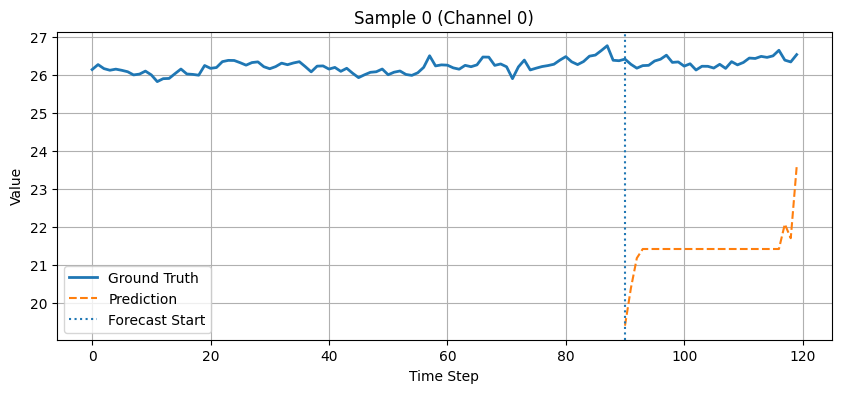

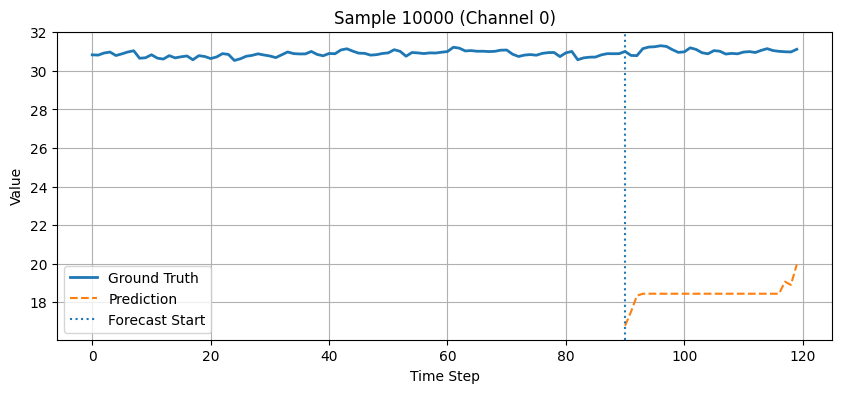

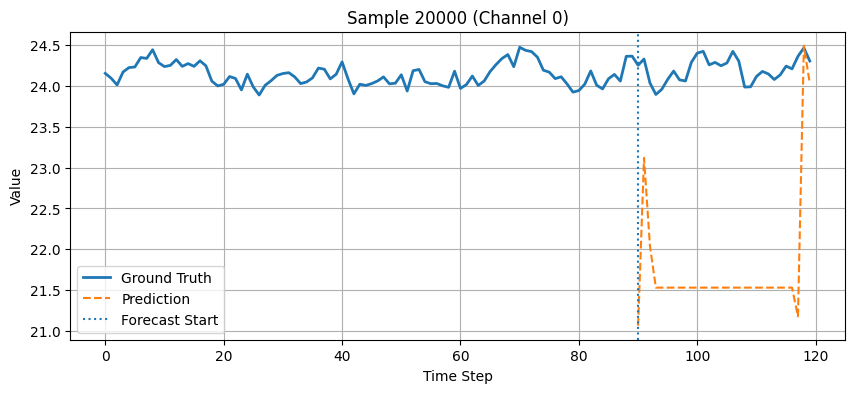

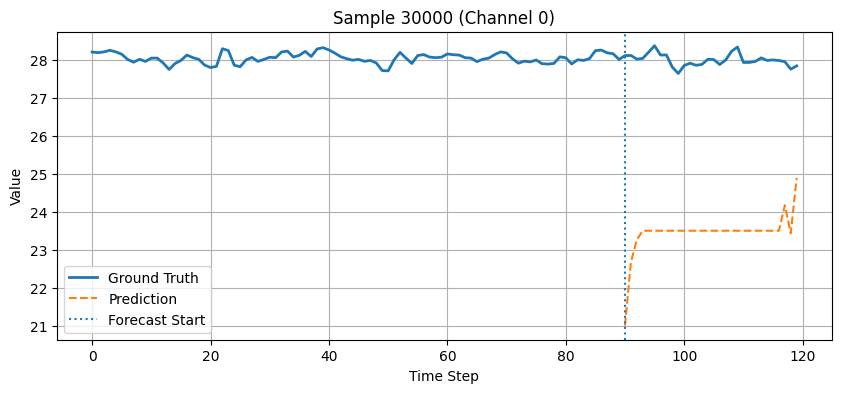

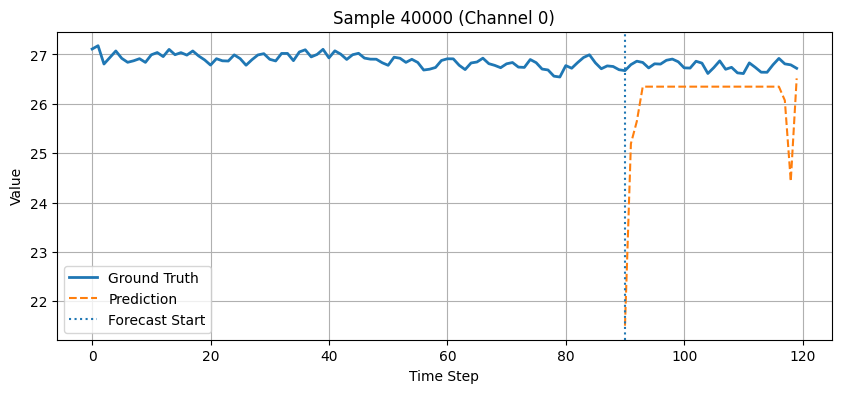

In [27]:
X_context_test, X_theta_test, X_delta_test, Y_target_test = testing_dataset

evaluate_and_plot(
    model=model,
    Z=Z,
    X_theta=X_theta_test,
    X_delta=X_delta_test,
    Y_target=Y_target_test,
    X_context=X_context_test,   # pass this if you have it
    indices=[*range(0, 50000, 10000)],
    channel=0,             # 0 = sphincter, 1 = gastric
    device=device,
)